<a href="https://colab.research.google.com/github/sumukhveeramalla/cs666student/blob/main/CS666_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

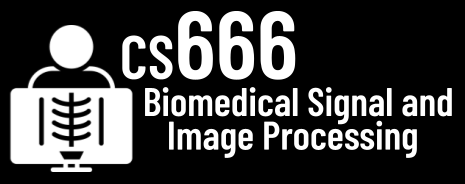
#Assignment 4

In [1]:
# NAME: Sumukh Veeramalla

In [2]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [3]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [4]:
# we are using mahotas again, so lets install it!
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 31.1 MB/s eta 0:00:00


In [5]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [6]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!
!wget -O xray.zip "https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&st=onzffmxz&dl=1"

--2026-04-21 23:27:02--  https://www.dropbox.com/scl/fi/sso8jwvfhoxqarp4zd3fb/xray.zip?rlkey=rvjqu3yj6gmw3r7gmst4ke9fl&st=onzffmxz&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucde9c01994d20e508c729a1d687.dl.dropboxusercontent.com/cd/0/inline/C_DfBwvHIcbxDg1i5OTDUIEstFv-RTGK-jeLqhaoiGvXV_zzvjjUI1O3QG25GRvXHvwAIwVXbkjjxfV7ZdNV50eu7S1QH52IP5N-TPbDxLGKpeqUjCo7bqgFSPqlOK17tRI/file?dl=1# [following]
--2026-04-21 23:27:03--  https://ucde9c01994d20e508c729a1d687.dl.dropboxusercontent.com/cd/0/inline/C_DfBwvHIcbxDg1i5OTDUIEstFv-RTGK-jeLqhaoiGvXV_zzvjjUI1O3QG25GRvXHvwAIwVXbkjjxfV7ZdNV50eu7S1QH52IP5N-TPbDxLGKpeqUjCo7bqgFSPqlOK17tRI/file?dl=1
Resolving ucde9c01994d20e508c729a1d687.dl.dropboxusercontent.com (ucde9c01994d20e508c729a1d687.dl.dropboxusercontent.com)... 162.125.6.15, 2620:100:601c:15::a27d:60

In [7]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
import zipfile
with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

NORMAL_DIR = 'normal/'
PNEUMONIA_DIR = 'pneumonia/'
COVID_DIR = 'covid/'

In [8]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

In [9]:
# TODO: Please display this image and print the dimensions!

Image shape:  (1858, 2090)


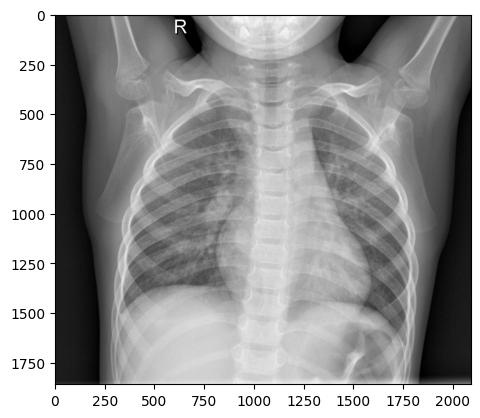

In [11]:
# TODO: YOUR CODE
import matplotlib.pyplot as plt
print("Image shape: ", img.shape)
plt.imshow(img, cmap="gray")

**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [12]:
folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [13]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) Convert RGB to Gray Scale i.e, loaded_image = mh.colors.rgb2gray(...)
# TODO: Operation 2) Resize image i.e, loaded_image = mh.imresize( loaded_image, (300, 300) )
# TODO: Operation 3) store in structured numpy array i.e, data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [14]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

<Figure size 640x480 with 0 Axes>

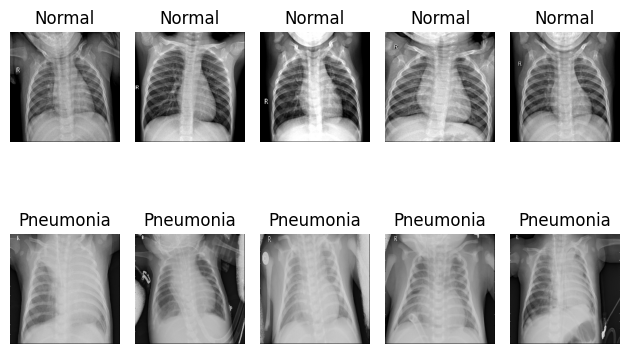

In [16]:
# TODO: YOUR CODE
plt.figure()
f, axarr = plt.subplots(2,5)

# first 5 NORMAL images
for i in range(5):
    axarr[0,i].imshow(data[0][i], cmap="gray")
    axarr[0,i].set_title("Normal")
    axarr[0,i].axis('off')

# first 5 PNEUMONIA images
for i in range(5):
    axarr[1,i].imshow(data[1][i], cmap="gray")
    axarr[1,i].set_title("Pneumonia")
    axarr[1,i].axis('off')

plt.tight_layout()
plt.show()

**Task 3:** Setup training and testing data. [15 Points]

In [17]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [18]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [19]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_train = np.array([0]*TRAINING_COUNT + [1]*TRAINING_COUNT + [2]*TRAINING_COUNT)

In [20]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [21]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
y_test = np.array([0]*TESTING_COUNT + [1]*TESTING_COUNT + [2]*TESTING_COUNT)

**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [22]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [23]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
clf = RandomForestClassifier()

In [24]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

In [25]:
# TODO: In just a few sentences, please explain how the Random Forest works.

In [26]:
# TODO: YOUR ANSWER

#A Random Forest is an ensemble of decision trees.
#Each tree is trained on a random subset of the training samples and, at each split, only a random subset of features is considered.
#For classification, every tree votes for a class and the forest predicts the class with the majority vote.
#This usually improves robustness and reduces overfitting compared with a single tree.

In [27]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

0.9083333333333333

In [28]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [29]:
# TODO: YOUR ANSWER

#The accuracy is quite good for such a simple baseline.
#It is somewhat surprising because we are using flattened raw pixels with a default Random Forest, without any feature engineering or deep learning.
#So we could say that random forest is able to differentiate between normal, pneumonia, covid based on flattened raw pixels it says images are very distinct.

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [30]:
# How many trees are used in Task 4?

In [31]:
# TODO: YOUR ANSWER
print("Number of trees: ", clf.n_estimators)

Number of trees:  100


In [32]:
# Now, please use a single tree and observe the testing performance.

In [33]:
# TODO: YOUR CODE
clf_new = RandomForestClassifier(n_estimators=1)
clf_new.fit(X_train, y_train)
clf_new.score(X_test, y_test)

0.7333333333333333

In [34]:
# Are you surprised?

In [35]:
# TODO: YOUR ANSWER

#No, using a single tree usually performs worse and is less stable than the full forest, so a drop in accuracy would not be surprising.
#The forest benefits from averaging many trees.But at the same time I could say 0.733 is even good accuracy.

**Bonus:** Let's take a closer look! [33 Points]

In [36]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [37]:
# TODO: YOUR CODE AND YOUR ANSWER
remaining_covid = data[2][TRAINING_COUNT + TESTING_COUNT:]
X_test_covid_only = np.zeros((len(remaining_covid), 300 * 300), dtype=np.float32)

for i, image in enumerate(remaining_covid):
    image = image.ravel()
    image /= image.max()
    X_test_covid_only[i] = image

y_test_covid_only = np.full(len(remaining_covid), 2, dtype=np.int32)
remaining_covid_accuracy = clf.score(X_test_covid_only, y_test_covid_only)

print("Remaining unseen covid image count:", len(remaining_covid))
print("Accuracy on remaining unseen covid images:", remaining_covid_accuracy)



Remaining unseen covid image count: 99
Accuracy on remaining unseen covid images: 0.9797979797979798


In [38]:
#The classifier generalizes fairly well to the held-out covid-only subset.

In [39]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

In [40]:
# TODO: YOUR CODE AND YOUR ANSWER

predictions = clf.predict(X_test_covid_only)
misclassified_idxs = np.where(predictions != y_test_covid_only)[0]

print("Misclassified indices:", misclassified_idxs.tolist())
print("Predicted labels for misclassified images:", predictions[misclassified_idxs].tolist())
print("True labels for misclassified images:", y_test_covid_only[misclassified_idxs].tolist())

Misclassified indices: [71, 84]
Predicted labels for misclassified images: [1, 0]
True labels for misclassified images: [2, 2]


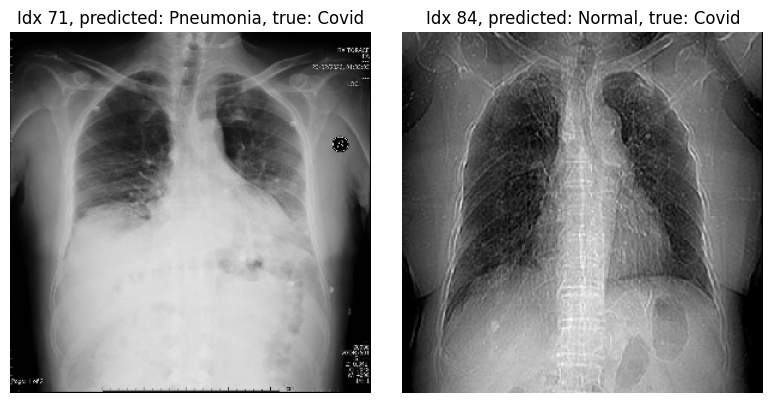

In [48]:
cols = 4 if len(misclassified_idxs) >= 4 else len(misclassified_idxs)
rows = int(np.ceil(len(misclassified_idxs) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)
label_map = {0: "Normal", 1: "Pneumonia", 2: "Covid"}

for ax in axes:
  ax.axis('off')

for plot_idx, img_idx in enumerate(misclassified_idxs):
  axes[plot_idx].imshow(remaining_covid[img_idx], cmap="gray")
  predicted_label = label_map[predictions[img_idx]]
  true_label = label_map[y_test_covid_only[img_idx]]
  axes[plot_idx].set_title(f'Idx {img_idx}, predicted: {predicted_label}, true: {true_label}')
  axes[plot_idx].axis('off')

plt.tight_layout()
plt.show()

In [49]:
#For image 71, the model predicted pneumonia even though the true label is covid because the lungs appear diffusely bright and opaque, which can overlap with the visual pattern seen in pneumonia cases.
#In other words, the classifier likely focused on the increased lung opacity, a feature that is not unique to COVID.

#For image 84, the model predicted normal even though the true label is covid because the lungs look comparatively clearer and show fewer obvious abnormal bright regions.
#Since the COVID-related findings appear subtle in this image, the classifier likely treated it as closer to a normal chest X-ray.

In [50]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw